# Exercise 1

In [2]:
# Import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import *

### 1. Solar abundances

- Read the following files: solar_Lodders2009, solar_s.dat, solar_r.dat. These files contain the observed total and inferred s- and r-process solar abundances respectively.

- Plot the log $\epsilon$ solar abundances from the above files vs the atomic number Z.

- Which elements are created through the r- and s- processes?

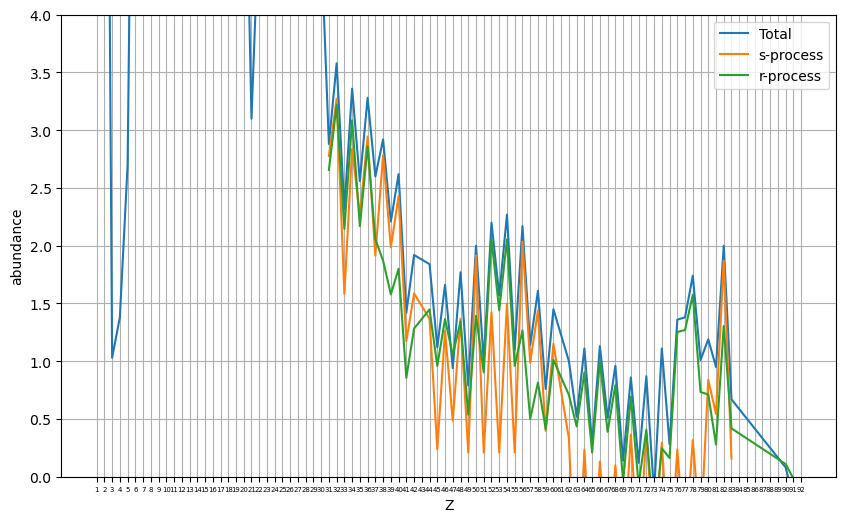

In [23]:
# Read and plot the solar abundances

# Set figure dimensions
fig, ax = plt.subplots(figsize=(10, 6))

# Load data from files
Z,logeps = np.loadtxt("solar_Lodders2009",unpack=True)
Z_s,logeps_s = np.loadtxt("solar_s.dat",unpack=True)
Z_r,logeps_r = np.loadtxt("solar_r.dat",unpack=True)

# Plot data
ax.plot(Z,logeps,label="Total")
ax.plot(Z_s,logeps_s,label="s-process")
ax.plot(Z_r,logeps_r,label="r-process")

# plot limits and labels
ax.set_ylim(0,4)
ax.set_ylabel("abundance")
ax.set_xlabel("Z")
ax.legend()
ax.grid(alpha=1)

plt.xticks(np.arange(int(min(Z)), int(max(Z))+1, 1), fontsize=5)
plt.show()

ANSWER: Elements which are mostly created through the r-process are for example Ge, Se as lighter examples or Os as a heavier example. For the s-process its mostly Sr or Zr for the lighter ones and Pb as one of the heaviest.

- Read the following file: solar_mfrac_anders_grevesse.txt.

- Plot the mass fraction of the elements vs their atomic number Z, their mass number A and their neutron number N.

- Which is the must abundant species in the solar system? How much is it in percentage? And the second must abundant?

- Locate on the plots the positions of the proton and neutron shell closures (magic numbers).

In [21]:
#Check if sum(Mfrac) \approx 1

total = np.sum(Mfrac)
print(total)

0.9999639545808662


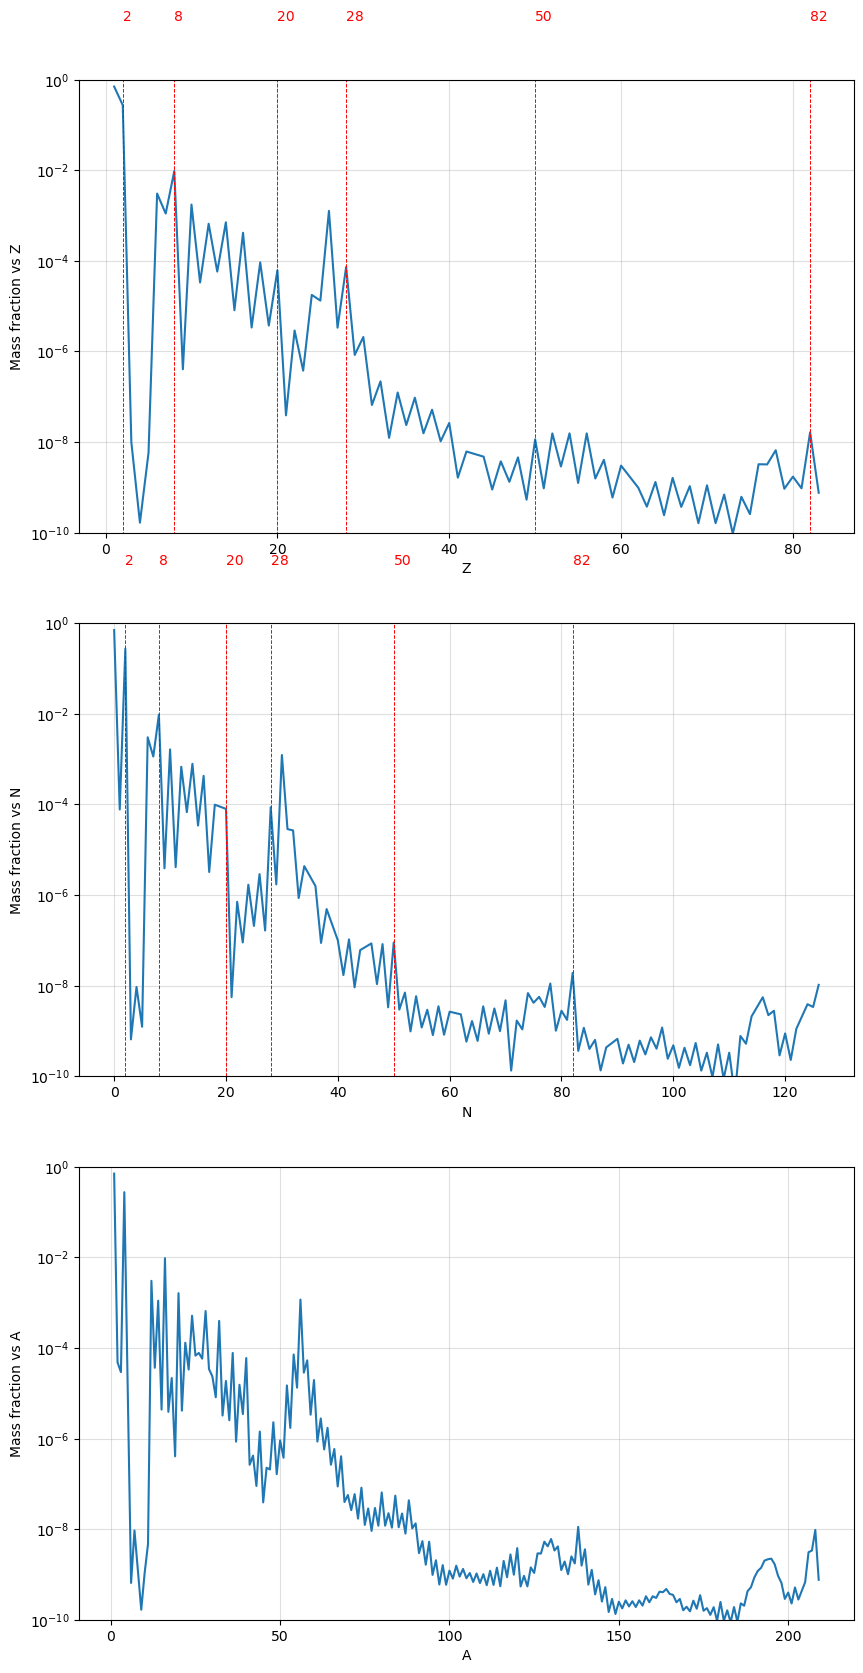

In [34]:
# Set figure dimensions
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(10, 20))

# Load data from file
data = np.loadtxt("solar_mfrac_anders_grevesse.txt")

#sum fractions of nuclei with same Z
Z = data[:, 0]
A = data[:, 1]
Mfrac = data[:, 2]

MsumZ = []
Z_unique = np.unique(Z)

MsumZ = [np.sum(Mfrac[Z==z]) for z in Z_unique] #List comprehension for unique Z values and their respective Mfrac vals. Summing over all these Mfrac vals

#plot vs Z
ax1.plot(Z_unique, MsumZ)

#sum fractions of nuclei with same N
MsumN = []
N = A - Z
N_unique = np.unique(N)

MsumN = [np.sum(Mfrac[N==n]) for n in N_unique] #analog to Z

#plot vs N
ax2.plot(N_unique,MsumN)

#sum fractions of nuclei with same A
MsumA = []
A_unique = np.unique(A)

MsumA = [np.sum(Mfrac[A==a]) for a in A_unique] #analog to Z

#plot vs A
ax3.plot(A_unique,MsumA)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

# magic numbers
magic=[2,8,20,28,50,82] # list of magic numbers
#plot vertical lines at magic numbers
ax1.vlines(magic,ymin=-6,ymax=13,linestyle='dashed',alpha=1,color='r',linewidth=.7)
#annotate magic numbers on the plot
for i in range(len(magic)):
    ax1.text(magic[i],2e1,str(magic[i]),color='r')
#same for ax2
#plot vertical lines at magic numbers
ax2.vlines(magic,ymin=-6,ymax=13,linestyle='dashed',alpha=1,color='r',linewidth=.7)
#annotate magic numbers on the plot
for i in range(len(magic)):
    ax2.text(magic[i],2e1,str(magic[i]),color='r')

# plot limits and labels
ax1.set_ylim(1e-10,1)
ax2.set_ylim(1e-10,1)
ax3.set_ylim(1e-10,1)
ax1.set_ylabel("Mass fraction vs Z")
ax2.set_ylabel("Mass fraction vs N")
ax3.set_ylabel("Mass fraction vs A")
ax1.set_xlabel("Z")
ax2.set_xlabel("N")
ax3.set_xlabel("A")
ax1.grid(alpha=.4)
ax2.grid(alpha=.4)
ax3.grid(alpha=.4)

plt.show()

In [35]:
idx_max1 = np.argmax(Mfrac)
idx_max2 = np.argsort(Mfrac)[-2]

Z_max1 = Z[idx_max1]
A_max1 = A[idx_max1]
Z_max2 = Z[idx_max2]
A_max2 = A[idx_max2]

amount_max1 = Mfrac[idx_max1] * 100
amount_max2 = Mfrac[idx_max2] * 100

In [36]:
# Find most abundant species
print('The most abundant species is: Hydrogen')
print('Z = ',Z_max1,' A =',A_max1)
print('The amount is: ',amount_max1,'%')

print('\nThe second most abundant species is:Helium')
print('Z =',Z_max2,' A =',A_max2)
print('The amount is: ',amount_max2,'%')

The most abundant species is: Hydrogen
Z =  1.0  A = 1.0
The amount is:  70.57 %

The second most abundant species is:Helium
Z = 2.0  A = 4.0
The amount is:  27.52 %


### 2. Gaia data

The Hertzsprung–Russell (H-R) diagram, is a scatter plot of stars showing the relationship between the stars' absolute magnitudes M or luminosities L versus their color or effective temperature T. 

- Read the gaia data of 1 M stars within 200 pc from the Sun: gaia/gaia-hrd-dr2-200pc.csv. The file contains the color BP-RP of the stars and their absolute magnitudes M. 

`gaiarec = np.recfromcsv("gaia-hrd-dr2-200pc.csv")`

`bp_rp, mg = gaiarec.bp_rp, gaiarec.mg` 

- Plot the H-R diagram.

- Try to locate on the diagram the Main sequence, the Giant branch and the White dwarfs.

- Add labels to show the stars' luminosity in units of the Sun luminosity. Use the relation $M_*-M_\odot=-2.5{\rm log}_{10}(L_*/L_\odot)$, where $M_\odot=4.83$.

`axy = ax.secondary_yaxis('right', functions=(mag2lum,lum2mag))`

C:\Users\Max\AppData\Local\Temp\ipykernel_14756\1172155425.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  h = ax.hist2d(_, _, bins=300, cmin=10, norm=colors.PowerNorm(0.5), cmap=mpl.cm.get_cmap('magma'), zorder=0.5)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

Error in callback <function _draw_all_if_interactive at 0x0000026609B7E5F0> (for post_execute):


OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

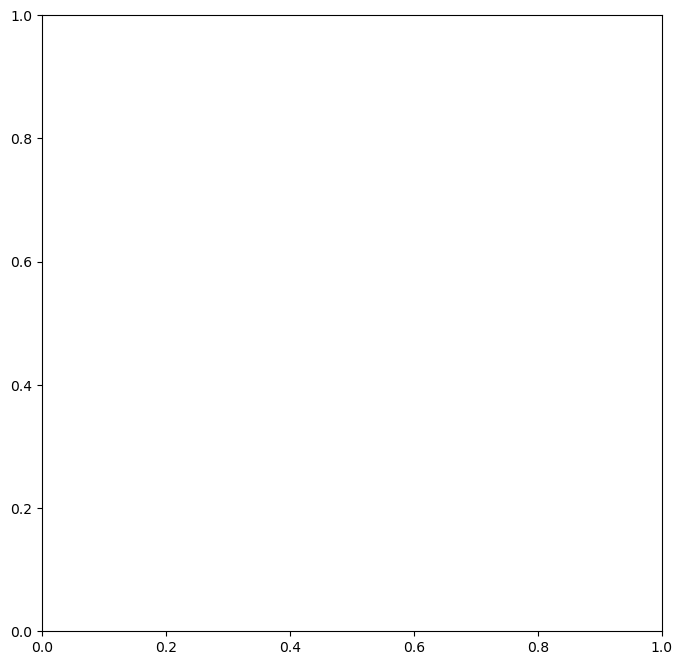

In [37]:
# use as reference https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram

#import data
gaiarec = np.recfromcsv("gaia-hrd-dr2-200pc.csv")
bp_rp, mg = gaiarec.bp_rp, gaiarec.mg
    
# plot the H-R diagram
plt.plot(mg, bp_rp)
#set figure dimension
fig, ax = plt.subplots(figsize=(8, 8))

# 2D-histogram with hist2d to show density of stars, showing only bins with more than 10 stars in them using cmin
h = ax.hist2d(_, _, bins=300, cmin=10, norm=colors.PowerNorm(0.5), cmap=mpl.cm.get_cmap('magma'), zorder=0.5)

# fill the rest with scatter
ax.scatter(_, _, alpha=0.05, s=1, color='k', zorder=0)

#invert the y axis for displaying magnitudes
ax.invert_yaxis()

#plot colorbar for the density
cbaxes = fig.add_axes([0.55, 0.85, 0.3, 0.02])             
cb = fig.colorbar(h[3], cax=cbaxes, orientation='horizontal')                

#annotate components
ax.text(_,_,'Main sequence')
ax.text(_,_,'Giant branch')
ax.text(_,_,'White dwarfs')

ax.set_xlabel(_)
ax.set_ylabel(_)
cb.set_label(_)
ax.set_xlim(_,_)

#define functions to convert quantities for secondary axis
def mag2lum(x):
    return _
def lum2mag(x):
    return _

# create secondary axis
axy = _
axy.set_ylabel(_)

#adjust ticks on axis
def myticks(x,pos):
    if x == 0: return "$0$"
    exponent = int(np.log10(x))
    coeff = x/10**exponent
    return r"$10^{{ {:2d} }}$".format(exponent)
axy.yaxis.set_major_locator(LogLocator())
axy.yaxis.set_major_formatter(FuncFormatter(myticks))

plt.show()

### 3. Binding energy per nucleon

The Atomic Mass Evaluation (AME) project is a long running international effort to provide the most reliable, and up-to-date set of nuclear masses for all known nuclides. It is the standard reference in nuclear physics when people talk about “measured nuclear masses.”
- Read the AME data of the known nuclides from: AME2020_massround.mas20.dat. The file header specifies the meaning of each value and symbol.
- Plot the binding energy per nucleon as a function of mass number. For each mass number, only plot the isotopes with the maximum binding energy per nucleon. For isotopes with mass number A > 35, plot every other data point to avoid overlap.
- Identify the isotopes with the highest binding energy per baryon and indicate which elements they correspond to.
- Why can elements heavier than iron not be synthesized through fusion?

In [ ]:
# read data from table
datafile = _
Z = []
A = []
BE = []
with open(datafile) as f:
    for line in f:
        if line.startswith('#'):
            continue
        Z.append(float(line.split()[1]))
        A.append(float(line.split()[2]))
        BE_string = line.split()[6]
        if '#' in BE_string:
            BE_string = BE_string.split('#')[0]
        BE.append(np.abs(float(BE_string))/1e3) # binding energy per nucleon in MeV
Z = np.array(Z)
A = np.array(A)
BE = np.array(BE)

#find isotope with highest binding energy per nucleon
A_max = _
Z_max = _
print('The isotope with the highest binding energy per nucleon is:')
print('Z =',_,' A =',_)

#reduce data to array of maximum binding energy per nucleon for each A
A_array = _
BE_max = _

#plot binding energy per nucleon vs A
plt.figure(figsize=(10,6))
_

# highlight the maximum
plt.scatter(_,_,color='C1',s=100,zorder=2)

# plot labels
plt.xlabel(_)
plt.ylabel(_)
plt.grid(alpha=.4)

plt.show()

The Bethe-Weizsäcker (semi-empirical) mass formula is a simple approximation for nuclear masses, based on the liquid drop model. The nucleus is modeled as an incompressible fluid with five contributions:
- Volume energy with $a_V$ = 15.56 MeV
- Surface energy with $a_S$ = 17.23 MeV
- Coulomb energy with $a_C$ = 0.69 MeV
- Asymmetry energy with $a_A$ = 23.28 MeV
- Pairing energy with $a_P$ = 11.2 MeV

With this approximation, the binding energy per nucleon of a nucleus with Z protons, N neutrons (and mass number A = Z + N) is given as:

$\frac{E_B}{A} = a_V − a_S \frac{1}{A^{1/3}} − a_C \frac{Z^2}{A^{4/3}} − a_A \frac{(N − Z)^2}{A^2} + \frac{δ(N, Z)}{2A^{3/2}}$

The pairing term δ(N, Z) is $a_P$ for even-even nuclei (even Z and even N ), 0 for odd-even nuclei (odd A), and $−a_P$ for odd-odd nuclei (odd N and odd Z).
- Plot the Bethe-Weizsäcker formula on top of the experimental data and check the agreement.

In [ ]:
# construct the Bethe-Weizsäcker formula (semi-empirical mass formula)
aV = _  # MeV
aS = _ # MeV
aC = _ # MeV
aA = _ # MeV
aP = _ # MeV

delta = _
BE_BW = _ # Bethe-Weizsäcker formula
BE_BW_max = _ # array of maximum binding energy per nucleon for each A from Bethe-Weizsäcker formula

#plot binding energy per nucleon vs Bethe-Weizsäcker formula
plt.figure(figsize=(10,6))
_
plt.ylim(_)
plt.xlabel(_)
plt.ylabel(_)
plt.legend()
plt.grid(alpha=.4)
plt.show()